In [1]:
pip install pandas numpy matplotlib scikit-learn networkx xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("../data/Synthetic Financial Dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
# Build the Graph

In [6]:
import networkx as nx

# Create directed graph (money flows direction matters)
G = nx.from_pandas_edgelist(
    df,
    source='nameOrig',
    target='nameDest',
    edge_attr='amount',
    create_using=nx.DiGraph()
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 9073900
Edges: 6362620


In [7]:
# Take sample first

In [8]:
df_sample = df.sample(n=100000, random_state=42)

In [9]:
# Create Graph Features (CORE PART)

In [10]:
# Degree (how many connections)
df_sample['orig_degree'] = df_sample['nameOrig'].map(dict(G.degree()))
df_sample['dest_degree'] = df_sample['nameDest'].map(dict(G.degree()))

In [11]:
# Add PageRank (very important feature)

In [12]:
pagerank = nx.pagerank(G)

df_sample['orig_pagerank'] = df_sample['nameOrig'].map(pagerank)
df_sample['dest_pagerank'] = df_sample['nameDest'].map(pagerank)

In [13]:
# trasection count

In [14]:
pair_counts = df_sample.groupby(['nameOrig', 'nameDest']).size()

df_sample['transaction_count'] = df_sample.set_index(['nameOrig', 'nameDest']).index.map(pair_counts)

In [15]:
# Prepare future

In [16]:
features = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'orig_degree',
    'dest_degree',
    'orig_pagerank',
    'dest_pagerank',
    'transaction_count'
]

X = df_sample[features]
y = df_sample['isFraud']

In [17]:
# train Model (XGBoost)

In [18]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [19]:
# Evaluate

In [20]:
from sklearn.metrics import classification_report

preds = (model.predict_proba(X_test)[:,1] > 0.3).astype(int)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19972
           1       0.61      0.71      0.66        28

    accuracy                           1.00     20000
   macro avg       0.80      0.86      0.83     20000
weighted avg       1.00      1.00      1.00     20000



In [21]:
# Compare (VERY IMPORTANT FOR PROJECT)

In [22]:
# Model 1: WITHOUT graph features

In [23]:
# Model 2: WITH graph features

In [24]:
# Model 1

In [25]:
features_base = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]

X_base = df_sample[features_base]
y = df_sample['isFraud']

In [26]:
# Model 2

In [27]:
features_graph = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'orig_degree',
    'dest_degree',
    'orig_pagerank',
    'dest_pagerank',
    'transaction_count'
]

X_graph = df_sample[features_graph]

In [28]:
# Train both models

In [29]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X_train_b, X_test_b, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, stratify=y, random_state=42
)

X_train_g, X_test_g, _, _ = train_test_split(
    X_graph, y, test_size=0.2, stratify=y, random_state=42
)

model_base = XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42
)

model_graph = XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42
)

model_base.fit(X_train_b, y_train)
model_graph.fit(X_train_g, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [30]:
# Evaluate BOTH

In [31]:
from sklearn.metrics import classification_report

# Predictions
pred_base = (model_base.predict_proba(X_test_b)[:,1] > 0.3).astype(int)
pred_graph = (model_graph.predict_proba(X_test_g)[:,1] > 0.3).astype(int)

print("BASE MODEL:\n")
print(classification_report(y_test, pred_base))

print("\nGRAPH MODEL:\n")
print(classification_report(y_test, pred_graph))

BASE MODEL:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19972
           1       0.57      0.71      0.63        28

    accuracy                           1.00     20000
   macro avg       0.79      0.86      0.82     20000
weighted avg       1.00      1.00      1.00     20000


GRAPH MODEL:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19972
           1       0.61      0.71      0.66        28

    accuracy                           1.00     20000
   macro avg       0.80      0.86      0.83     20000
weighted avg       1.00      1.00      1.00     20000



In [32]:
# PR Curve Comparison

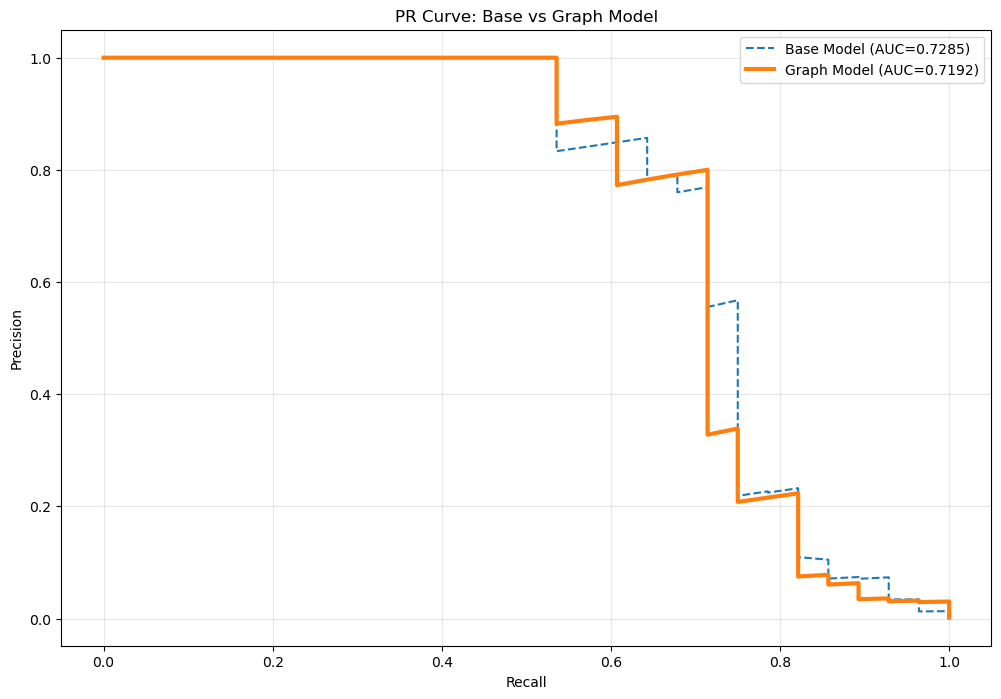

In [132]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

# Base model
probs_base = model_base.predict_proba(X_test_b)[:,1]
p, r, _ = precision_recall_curve(y_test, probs_base)
plt.plot(r, p, linestyle='--', label=f"Base Model (AUC={auc(r,p):.4f})")

# Graph model (highlight)
probs_graph = model_graph.predict_proba(X_test_g)[:,1]
p, r, _ = precision_recall_curve(y_test, probs_graph)
plt.plot(r, p, linewidth=3, label=f"Graph Model (AUC={auc(r,p):.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve: Base vs Graph Model")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("pr_curve.png", dpi=300, bbox_inches='tight')

plt.show()

In [34]:
# Feature Importance

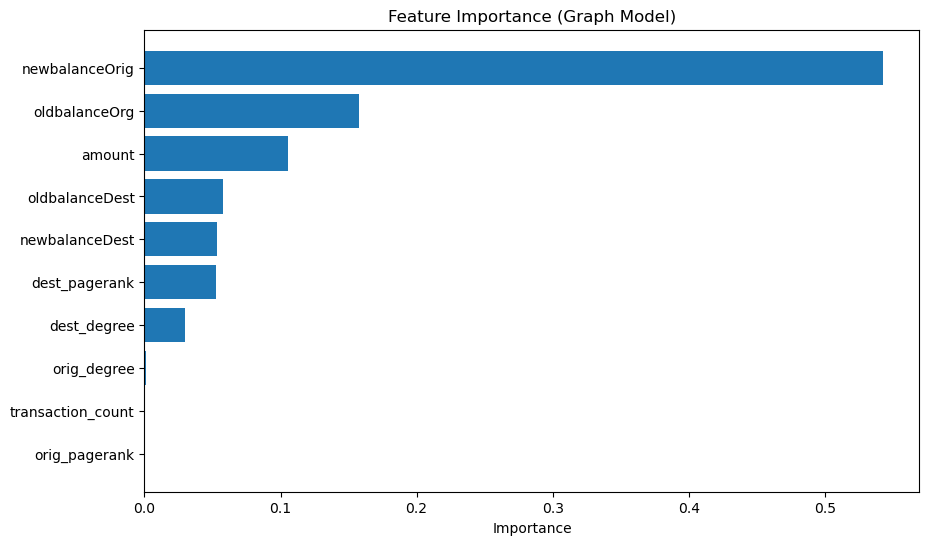

In [142]:
import pandas as pd

importance_df = pd.DataFrame({
    'feature': X_train_g.columns,
    'importance': importance
}).sort_values(by='importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.title("Feature Importance (Graph Model)")
plt.xlabel("Importance")
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

In [36]:
# Tune Threshold

In [37]:
from sklearn.metrics import precision_recall_curve

probs = model_graph.predict_proba(X_test_g)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Convert to F1 score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])

Best Threshold: 0.96417046
Best F1: 0.7755101991836736


In [38]:
preds = (probs > best_threshold).astype(int)

In [39]:
# Handle Class Imbalance Better

In [40]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

706.9646017699115


In [41]:
model_graph = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

In [42]:
# Add In-Degree / Out-Degree

In [43]:
df_sample['orig_out_degree'] = df_sample['nameOrig'].map(dict(G.out_degree()))
df_sample['dest_in_degree'] = df_sample['nameDest'].map(dict(G.in_degree()))

In [44]:
# Add Transaction Velocity

In [45]:
df_sample['transaction_velocity'] = df_sample.groupby('nameOrig')['step'].diff().fillna(0)

In [46]:
# Add Balance Change Ratio

In [47]:
df_sample['balance_change'] = (
    df_sample['oldbalanceOrg'] - df_sample['newbalanceOrig']
) / (df_sample['amount'] + 1)

In [48]:
# Update features

In [49]:
features_graph = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'orig_degree',
    'dest_degree',
    'orig_pagerank',
    'dest_pagerank',
    'transaction_count',
    'orig_out_degree',
    'dest_in_degree',
    'transaction_velocity',
    'balance_change'
]

In [50]:
model_graph.fit(X_train_g, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [51]:
model_graph = XGBClassifier(
    n_estimators=200,      # lower = less overfitting
    max_depth=5,           # reduce complexity
    learning_rate=0.05,    # slower learning = better generalization
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

model_graph.fit(X_train_g, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [52]:
preds = (model_graph.predict_proba(X_test_g)[:,1] > best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19972
           1       0.79      0.68      0.73        28

    accuracy                           1.00     20000
   macro avg       0.90      0.84      0.87     20000
weighted avg       1.00      1.00      1.00     20000



In [53]:
# Install SHAP

In [54]:
# What SHAP Does (Simple)
# Why a transaction is fraud
# Which features influenced the prediction

In [55]:
# Initialize SHAP

In [56]:
!pip install shap

In [57]:
import sys
print(sys.executable)

/opt/anaconda3/envs/fraud_env/bin/python


In [58]:
import sys
!{sys.executable} -m pip install shap

In [90]:
def model_predict(data):
    return model_graph.predict_proba(data)

In [92]:
X_sample_np = X_sample.values
background_np = X_sample.iloc[:50].values

In [94]:
import shap

explainer = shap.KernelExplainer(
    model_predict,   # ✅ wrapper instead of model directly
    background_np
)

In [96]:
shap_values = explainer.shap_values(X_sample_np)

100%|████████████████████████████████████████| 100/100 [00:00<00:00, 281.41it/s]


In [100]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[1].shape)
print(X_sample_np.shape)

<class 'numpy.ndarray'>
100
(10, 2)
(100, 10)


In [102]:
shap_vals = shap_values[1]

# If extra column exists (bias term)
if shap_vals.shape[1] != X_sample_np.shape[1]:
    shap_vals = shap_vals[:, :X_sample_np.shape[1]]

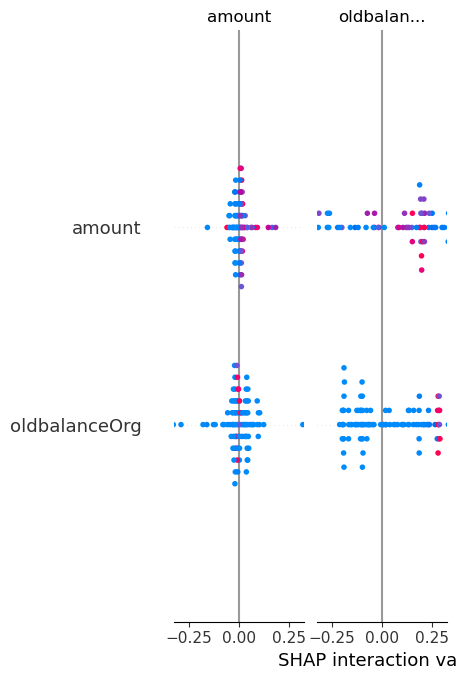

In [106]:
shap.summary_plot(
    shap_values,
    X_sample_np,
    feature_names=X_sample.columns
)

In [110]:
print("SHAP shape:", shap_vals.shape)
print("X shape:", X_sample_np.shape)

SHAP shape: (10, 2)
X shape: (100, 10)


In [118]:
import shap
import numpy as np

# small sample
X_sample = X_test_g.sample(100, random_state=42)

# convert to numpy
X_sample_np = X_sample.values

# create masker (THIS is key)
masker = shap.maskers.Independent(X_sample_np)

# use function wrapper
def model_predict(data):
    return model_graph.predict_proba(data)[:, 1]  # fraud class only

explainer = shap.Explainer(model_predict, masker)

In [120]:
shap_values = explainer(X_sample_np)

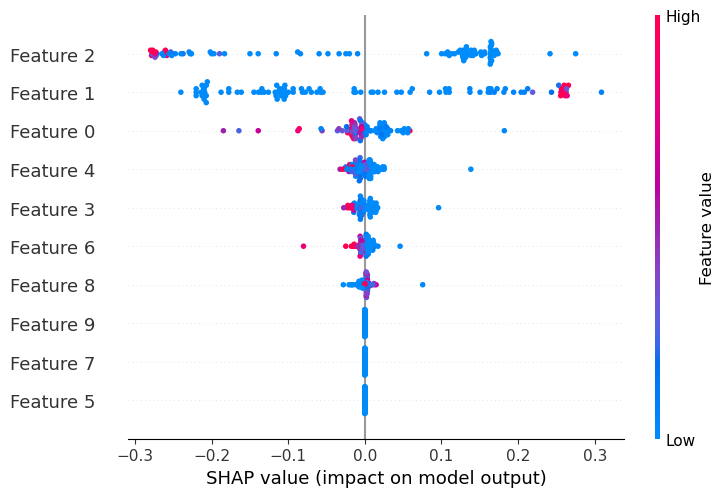

<Figure size 640x480 with 0 Axes>

In [126]:
import shap
import matplotlib.pyplot as plt

# Generate plot
shap.plots.beeswarm(shap_values)

# Save BEFORE show
plt.savefig("shap_summary.png", dpi=300, bbox_inches='tight')

# Then show
plt.show()

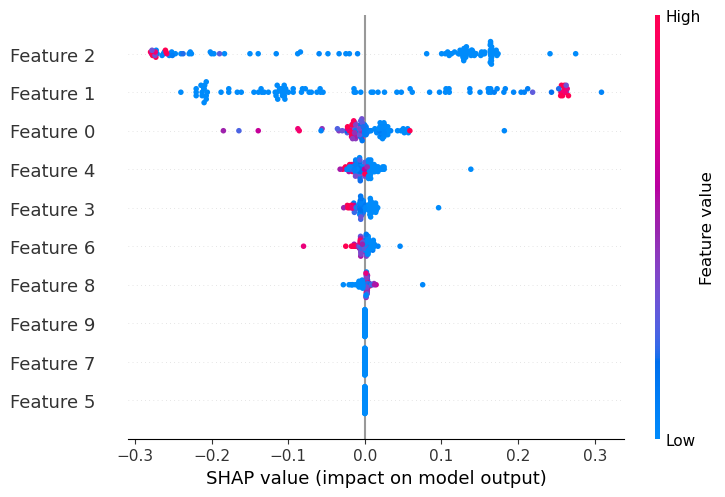

In [128]:
fig = shap.plots.beeswarm(shap_values, show=False)

fig.figure.savefig("shap_summary.png", dpi=300, bbox_inches='tight')

In [130]:
import os
print(os.path.exists("shap_summary.png"))

True
